# What is Convolution ?
Convolution is a linear operation similar to a linear equation, dot product, or matrix multiplication. \\
Convolution preserves the relationship between elements, and it requires fewer parameters than other methods. \\

You can see the relationship between the different methods:

$linear \ equation :y=wx+b$

$linear\ equation\ with\ multiple \ variables \ where \ \mathbf{x} \ is \ a \ vector \ y=\mathbf{wx}+b$

$ \ matrix\ multiplication \ where \ \mathbf{X} \ is \ a \ matrix \ \mathbf{y}=\mathbf{wX}+\mathbf{b} $

$\ convolution \ where \ \mathbf{X} \ and \ \mathbf{Y} \ is \ a \ tensor \  \mathbf{Y}=\mathbf{w}*\mathbf{X}+\mathbf{b}$

In convolution, the parameter <b>w</b> is called a kernel. You can perform convolution on images where you let the variable image denote the variable X and w denote the parameter.

<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.1xw.png" width = 500, align = "center">





In [ ]:
import torch
import torch.nn as nn

In [ ]:
conv = nn.Conv2d(in_channels = 1, out_channels = 1, kernel_size = 3)

print(conv.weight.shape, "\n", "*"*60, "\n")
print(conv.weight, "\n", "*"*60, "\n")
print(conv.bias, "\n", "*"*60, "\n")

torch.Size([1, 1, 3, 3]) 
 ************************************************************ 

Parameter containing:
tensor([[[[-0.0255, -0.3214, -0.0186],
          [ 0.0217,  0.0435,  0.1906],
          [ 0.2834, -0.2586,  0.0287]]]], requires_grad=True) 
 ************************************************************ 

Parameter containing:
tensor([0.1062], requires_grad=True) 
 ************************************************************ 



In [ ]:
conv.state_dict()['weight'][0][0]=torch.tensor([[1.0,0.0,-1],[2.0,0.0,-2],[1.0,0.0,-1.0]])
conv.state_dict()['bias'][0]=0.0

print(conv.weight, "\n", "*"*60, "\n")
print(conv.bias, "\n", "*"*60, "\n")

Parameter containing:
tensor([[[[ 1.,  0., -1.],
          [ 2.,  0., -2.],
          [ 1.,  0., -1.]]]], requires_grad=True) 
 ************************************************************ 

Parameter containing:
tensor([0.], requires_grad=True) 
 ************************************************************ 



In [ ]:
img = torch.ones(1,1,5,5)
print(img, "\n", "*"*60, "\n")

img[0,0,:,2] = 0
print(img, "\n", "*"*60, "\n")

z = conv(img)
print(z, "\n", "*"*60, "\n")

tensor([[[[1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1.]]]]) 
 ************************************************************ 

tensor([[[[1., 1., 0., 1., 1.],
          [1., 1., 0., 1., 1.],
          [1., 1., 0., 1., 1.],
          [1., 1., 0., 1., 1.],
          [1., 1., 0., 1., 1.]]]]) 
 ************************************************************ 

tensor([[[[ 4.,  0., -4.],
          [ 4.,  0., -4.],
          [ 4.,  0., -4.]]]], grad_fn=<ConvolutionBackward0>) 
 ************************************************************ 



The kernel performs at the element-level multiplication on every element in the image in the corresponding region.
The values are then added together.
The kernel is then shifted and the process is repeated.

<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.1convltuon.gif" width = 500, align = "center">



## Determining the Size of the Output

The size of the output is an important parameter.Assume square images. For rectangular images, the same formula can be used in for each dimension independently.

Let M be the size of the input and K be the size of the kernel. The size of the output is given by the following formula:

$$M\_{new}=M-K+1$$



In [ ]:
# Create Kernel of size 2X2
K=2
conv1=nn.Conv2d(in_channels=1,out_channels=1,kernel_size=K)
conv1.state_dict()['weight'][0][0]=torch.tensor([[1.0,1.0],[1.0,1.0]])
conv1.state_dict()['bias'][0]=0.0  #In PyTorch, state_dict() is a Python dictionary object that maps each layer to its learnable parameters (weights and biases).
                                   #It's essentially a dictionary containing the entire state of your model, including its layers and their parameters.
print(conv1.state_dict(), "\n", "*"*60, "\n")
print(conv1.weight.shape, "\n", "*"*60, "\n")
print(conv1.weight, "\n", "*"*60, "\n")
print(conv1.bias, "\n", "*"*60, "\n")

OrderedDict({'weight': tensor([[[[1., 1.],
          [1., 1.]]]]), 'bias': tensor([0.])}) 
 ************************************************************ 

torch.Size([1, 1, 2, 2]) 
 ************************************************************ 

Parameter containing:
tensor([[[[1., 1.],
          [1., 1.]]]], requires_grad=True) 
 ************************************************************ 

Parameter containing:
tensor([0.], requires_grad=True) 
 ************************************************************ 



In [ ]:
# create image of size 4 x 4
M=4
image1=torch.ones(1,1,M,M)
print(image1.shape, "\n", "*"*60, "\n")
print(image1, "\n", "*"*60, "\n")

torch.Size([1, 1, 4, 4]) 
 ************************************************************ 

tensor([[[[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]]]]) 
 ************************************************************ 



<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.1kernal2.png" width = 500, align = "center">


The following equation provides the output:
$$M\_{new}=M-K+1$$
$$M\_{new}=4-2+1$$
$$M\_{new}=3$$
The following animation illustrates the process: The first iteration of the kernel overlay of the images produces one output. As the kernel is of size K, there are M-K  elements for the kernel to move in the horizontal direction. The same logic applies to the vertical direction.
<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.1outsize.gif" width = 500, align = "center">


In [ ]:
# perform conv and verify the size
z1=conv1(image1)
print("z1:",z1, "\n", "*"*60, "\n")
print("shape:",z1.shape, "\n", "*"*60, "\n")

z1: tensor([[[[4., 4., 4.],
          [4., 4., 4.],
          [4., 4., 4.]]]], grad_fn=<ConvolutionBackward0>) 
 ************************************************************ 

shape: torch.Size([1, 1, 3, 3]) 
 ************************************************************ 



## Stride parameter
The parameter stride changes the number of shifts the kernel moves per iteration. As a result, the output size also changes and is given by the following formula:
$$M\_{new}=\dfrac{M-K}{stride}+1$$
* Create a convolution object with a stride of 2:


In [ ]:
conv3 = nn.Conv2d(in_channels=1, out_channels=1,kernel_size=2,stride=2)
conv3.state_dict()['weight'][0][0]=torch.tensor([[1.0,1.0],[1.0,1.0]])
conv3.state_dict()['bias'][0]=0.0
print(conv3.state_dict(), "\n", "*"*60, "\n")

OrderedDict({'weight': tensor([[[[1., 1.],
          [1., 1.]]]]), 'bias': tensor([0.])}) 
 ************************************************************ 



For an image with a size of 4, calculate the output size:
$$M\_{new}=\dfrac{M-K}{stride}+1$$
$$M\_{new}=\dfrac{4-2}{2}+1$$
$$M\_{new}=2$$
The following animation illustrates the process: The first iteration of the kernel overlay of the images produces one output. Because the kernel is of size K, there are M-K=2 elements. The stride is 2 because it will move 2 elements at a time. As a result, you divide M-K by the stride value 2:
<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.1stride2.gif" width = 500, align = "center">

In [ ]:
z3=conv3(image1)
print("z3:",z3, "\n", "*"*60, "\n")
print("shape:",z3.shape[2:4], "\n", "*"*60, "\n")

z3: tensor([[[[4., 4.],
          [4., 4.]]]], grad_fn=<ConvolutionBackward0>) 
 ************************************************************ 

shape: torch.Size([2, 2]) 
 ************************************************************ 



## Zero Padding
As you apply successive convolutions, the image will shrink. You can apply zero padding to keep the image at a reasonable size, which also holds information at the borders.
In addition, you might not get integer values for the size of the kernel. Consider the following image:
Try performing convolutions with the <code>kernel_size=2</code> and a <code>stride=3</code>. Use these values:

$$M\_{new}=\dfrac{M-K}{stride}+1$$
$$M\_{new}=\dfrac{4-2}{3}+1$$
$$M\_{new}=1.666$$


In [ ]:
print(image1, "\n", "*"*60, "\n")
conv4 = nn.Conv2d(in_channels=1, out_channels=1,kernel_size=2,stride=3)
conv4.state_dict()['weight'][0][0]=torch.tensor([[1.0,1.0],[1.0,1.0]])
conv4.state_dict()['bias'][0]=0.0
# conv4.state_dict()
z4=conv4(image1)
print("z4:",z4, "\n", "*"*60, "\n")

tensor([[[[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]]]]) 
 ************************************************************ 

z4: tensor([[[[4.]]]], grad_fn=<ConvolutionBackward0>) 
 ************************************************************ 



You can add rows and columns of zeros around the image. This is called **padding**. In the constructor <code>Conv2d</code>, you specify the number of rows or columns of zeros that you want to add with the parameter padding.

For a square image, you merely pad an extra column of zeros to the first column and the last column. Repeat the process for the rows. As a result, for a square image, the width and height is `the original size + 2 x the number of padding elements specified`. You can then determine the size of the output after subsequent operations accordingly as shown in the following equation where you determine the size of an image after padding and then applying a convolutions kernel of size K.
$$M'=M+2 \times padding$$
$$M\_{new}=M'-K+1$$

Consider the following example:

In [ ]:
conv5 = nn.Conv2d(in_channels=1, out_channels=1,kernel_size=2,stride=3,padding=1)
conv5.state_dict()['weight'][0][0]=torch.tensor([[1.0,1.0],[1.0,1.0]])
conv5.state_dict()['bias'][0]=0.0
# conv5.state_dict()

z5=conv5(image1)

print("z5:",z5.shape, "\n", "*"*60, "\n")
print("z4(without padding):",z4.shape, "\n", "*"*60, "\n")

z5: torch.Size([1, 1, 2, 2]) 
 ************************************************************ 

z4(without padding): torch.Size([1, 1, 1, 1]) 
 ************************************************************ 



The process is summarized as:

<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.1zeropad.gif" width = 500, align = "center">


## Question: You have an image of size 4. The parameters are as follows  kernel_size=2,stride=2,padding=3. What is the size of the output?



```
(M+2P-K)/stride +1
(4+(3*2)-2)/2 +1
5
```



In [ ]:
image = torch.ones(1,1,4,4)
conv3 = nn.Conv2d(in_channels=1, out_channels=1,kernel_size=2,padding=3,stride=2)

conv3.state_dict()['weight'][0][0]=torch.tensor([[1.0,1.0],[1.0,1.0]])
conv3.state_dict()['bias'][0]=0.0

print(conv3(image).shape[2:4], "\n", "*"*60, "\n")

torch.Size([5, 5]) 
 ************************************************************ 



## Activation Functions and Max Polling

### Activation Fn

Just like a neural network, you apply an activation function to the activation map as shown in the following image:
<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.3block_digram.png" width = 1000, align = "center">


In [ ]:
conv = nn.Conv2d(in_channels=1, out_channels=1,kernel_size=3)
Gx=torch.tensor([[1.0,0,-1.0],[2.0,0,-2.0],[1.0,0,-1.0]])
conv.state_dict()['weight'][0][0]=Gx
conv.state_dict()['bias'][0]=0.0
conv.state_dict()

OrderedDict([('weight',
              tensor([[[[ 1.,  0., -1.],
                        [ 2.,  0., -2.],
                        [ 1.,  0., -1.]]]])),
             ('bias', tensor([0.]))])

In [ ]:
image=torch.zeros(1,1,5,5)
image[0,0,:,2]=1
image

tensor([[[[0., 0., 1., 0., 0.],
          [0., 0., 1., 0., 0.],
          [0., 0., 1., 0., 0.],
          [0., 0., 1., 0., 0.],
          [0., 0., 1., 0., 0.]]]])

In [ ]:
Z=conv(image)
print(Z, "\n", "*"*60, "\n")

A=torch.relu(Z)
print(A, "\n", "*"*60, "\n")

tensor([[[[-4.,  0.,  4.],
          [-4.,  0.,  4.],
          [-4.,  0.,  4.]]]], grad_fn=<ConvolutionBackward0>) 
 ************************************************************ 

tensor([[[[0., 0., 4.],
          [0., 0., 4.],
          [0., 0., 4.]]]], grad_fn=<ReluBackward0>) 
 ************************************************************ 



The Relu function is applied to each element. All the elements less than zero are mapped to zero. The remaining components do not change.
<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.2.3_block_example.gif" width = 1000, align = "center">


### Max Pooling

In [ ]:
image1=torch.zeros(1,1,4,4)
image1[0,0,0,:]=torch.tensor([1.0,2.0,3.0,-4.0])
image1[0,0,1,:]=torch.tensor([0.0,2.0,-3.0,0.0])
image1[0,0,2,:]=torch.tensor([0.0,2.0,3.0,1.0])

print(image1, "\n", "*"*60, "\n")

tensor([[[[ 1.,  2.,  3., -4.],
          [ 0.,  2., -3.,  0.],
          [ 0.,  2.,  3.,  1.],
          [ 0.,  0.,  0.,  0.]]]]) 
 ************************************************************ 



Max pooling simply takes the maximum value in each region. Consider the following image. For the first region, max pooling simply takes the largest element in a yellow region.

<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.3maxpool_1.png" width = 500, align = "center">

The region shifts, and the process is repeated. The process is similar to convolution and is demonstrated in the following figure:

<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.3_max_pool_animation.gif" width = 500, align = "center">


In [ ]:
max1=torch.nn.MaxPool2d(2,stride=1)
max1(image1)

tensor([[[[2., 3., 3.],
          [2., 3., 3.],
          [2., 3., 3.]]]])

If the stride is set to None (its defaults setting), the process will simply take the maximum in a prescribed area and shift over accordingly as shown in the following figure:

<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.3_max_pool_animation_2.gif" width = 500, align = "center">


In [ ]:
max1=torch.nn.MaxPool2d(2, stride = None)
max1(image1)

tensor([[[[2., 3.],
          [2., 3.]]]])

## Multiple Output Channels
In Pytroch, you can create a <code>Conv2d</code> object with multiple outputs. For each channel, a kernel is created, and each kernel performs a convolution independently. As a result, the number of outputs is equal to the number of channels. This is demonstrated in the following figure.

### **Case 1: Single input multiple output**

 The number 9 is convolved with three kernels: each of a different color. There are three different activation maps represented by the different colors.

<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.2activationmaps.png" width = 750, align = "center">

Symbolically, this can be represented as follows:

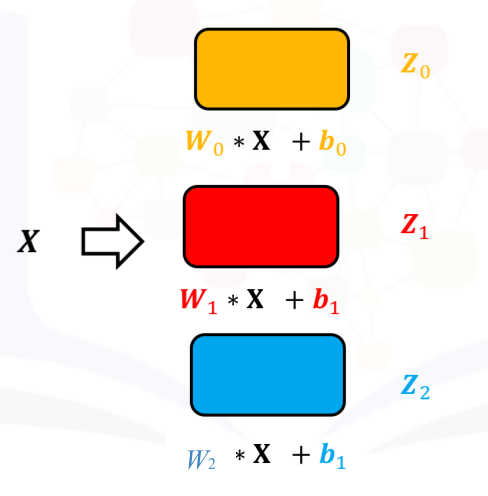

Create a <code>Conv2d</code> with three channels:

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
conv1 = nn.Conv2d(in_channels=1, out_channels=3,kernel_size=3)

Gx=torch.tensor([[1.0,0,-1.0],[2.0,0,-2.0],[1.0,0.0,-1.0]])
Gy=torch.tensor([[1.0,2.0,1.0],[0.0,0.0,0.0],[-1.0,-2.0,-1.0]])

print(conv1.weight.shape, "\n", "*"*60, "\n")
print(conv1.bias.shape, "\n", "*"*60, "\n")

conv1.state_dict()['weight'][0][0]=Gx # kernel_1
conv1.state_dict()['weight'][1][0]=Gy # Kernel_2
conv1.state_dict()['weight'][2][0]=torch.ones(3,3) # Kernel_3

conv1.state_dict()['bias'][:]=torch.tensor([0.0,0.0,0.0])

print(conv1.state_dict()['bias'])
for x in conv1.state_dict()['weight']:
    print(x, "\n", "*"*60, "\n")

torch.Size([3, 1, 3, 3]) 
 ************************************************************ 

torch.Size([3]) 
 ************************************************************ 

tensor([0., 0., 0.])
tensor([[[ 1.,  0., -1.],
         [ 2.,  0., -2.],
         [ 1.,  0., -1.]]]) 
 ************************************************************ 

tensor([[[ 1.,  2.,  1.],
         [ 0.,  0.,  0.],
         [-1., -2., -1.]]]) 
 ************************************************************ 

tensor([[[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]]) 
 ************************************************************ 



tensor([[[[0., 0., 1., 0., 0.],
          [0., 0., 1., 0., 0.],
          [0., 0., 1., 0., 0.],
          [0., 0., 1., 0., 0.],
          [0., 0., 1., 0., 0.]]]]) 
 ************************************************************ 



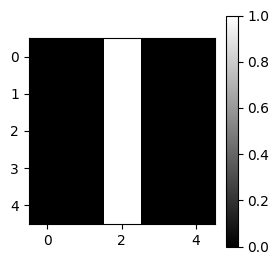

In [ ]:
image=torch.zeros(1,1,5,5)
image[0,0,:,2]=1
print(image, "\n", "*"*60, "\n")

plt.figure(figsize=(3,3))
plt.imshow(image[0,0,:,:].numpy(), interpolation='nearest', cmap=plt.cm.gray)
plt.colorbar()
plt.show()

torch.Size([1, 3, 3, 3]) 
 ************************************************************ 

tensor([[-4.,  0.,  4.],
        [-4.,  0.,  4.],
        [-4.,  0.,  4.]], grad_fn=<UnbindBackward0>) 
 ************************************************************ 



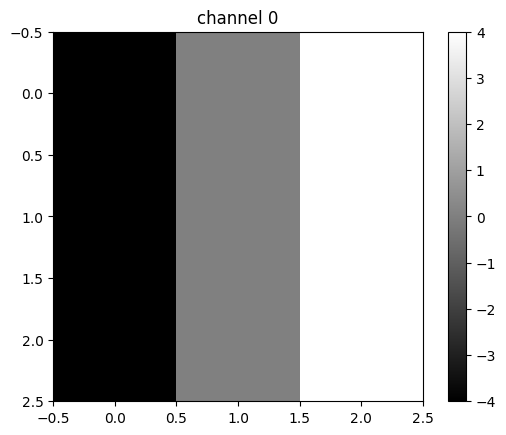

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], grad_fn=<UnbindBackward0>) 
 ************************************************************ 



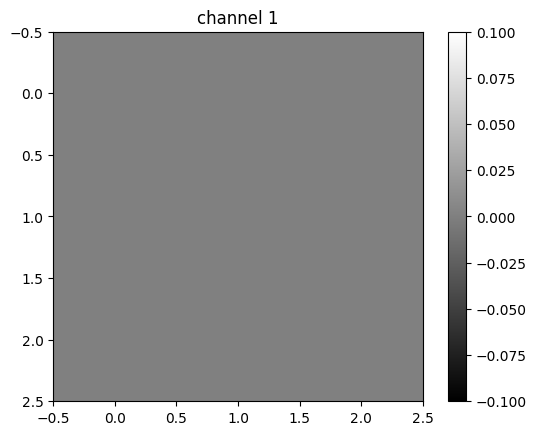

tensor([[3., 3., 3.],
        [3., 3., 3.],
        [3., 3., 3.]], grad_fn=<UnbindBackward0>) 
 ************************************************************ 



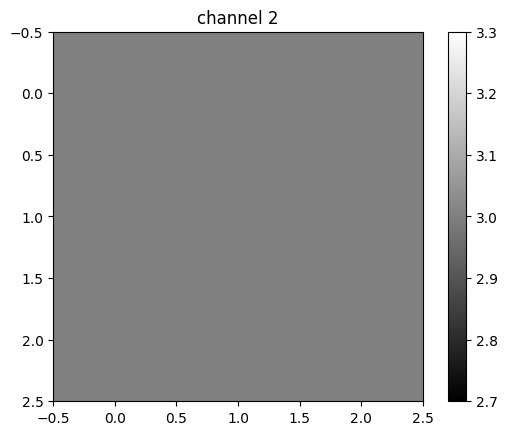

In [ ]:
out=conv1(image)

print(out.shape, "\n", "*"*60, "\n")

for channel,image in enumerate(out[0]):
    plt.imshow(image.detach().numpy(), interpolation='nearest', cmap=plt.cm.gray)
    print(image, "\n", "*"*60, "\n")
    plt.title("channel {}".format(channel))
    plt.colorbar()
    plt.show()

Different kernels can be used to detect various features in an image. You can see that the first channel fluctuates, and the second two channels produce a constant value. The following figure summarizes the process:

<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.2outputsgray.png" width = 750, align = "center">


tensor([[[[0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.],
          [1., 1., 1., 1., 1.],
          [0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0.]]]]) 
 ************************************************************ 



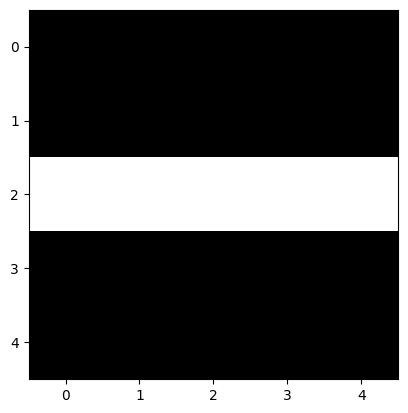

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], grad_fn=<UnbindBackward0>) 
 ************************************************************ 



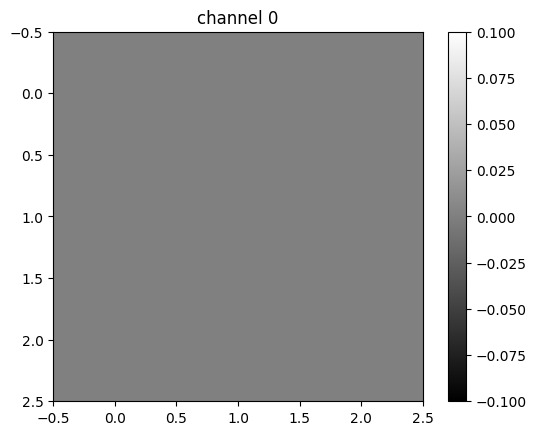

tensor([[-4., -4., -4.],
        [ 0.,  0.,  0.],
        [ 4.,  4.,  4.]], grad_fn=<UnbindBackward0>) 
 ************************************************************ 



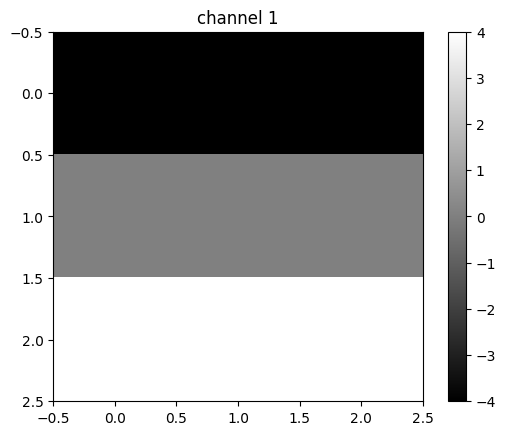

tensor([[3., 3., 3.],
        [3., 3., 3.],
        [3., 3., 3.]], grad_fn=<UnbindBackward0>) 
 ************************************************************ 



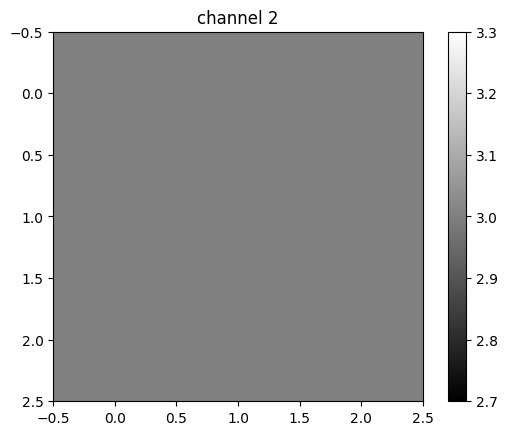

In [ ]:
# if use different image results will be different
image1=torch.zeros(1,1,5,5)
image1[0,0,2,:]=1
print(image1, "\n", "*"*60, "\n")
plt.imshow(image1[0,0,:,:].detach().numpy(), interpolation='nearest', cmap=plt.cm.gray)
plt.show()

out1=conv1(image1)
for channel,image in enumerate(out1[0]):
    plt.imshow(image.detach().numpy(), interpolation='nearest', cmap=plt.cm.gray)
    print(image, "\n", "*"*60, "\n")
    plt.title("channel {}".format(channel))
    plt.colorbar()
    plt.show()

Summary :

<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.2ouputsgray2.png" width = 750, align = "center">


### Case 2: Multiple Input Channels

For two inputs, you can create two kernels. Each kernel performs a convolution on its associated input channel. The resulting output is added together as shown:


<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.22chanalsinput.png" width = 750, align = "center">




tensor([[[[ 0.,  0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.,  0.],
          [-2., -2., -2., -2., -2.],
          [ 0.,  0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.,  0.]],

         [[ 0.,  0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.,  0.],
          [ 1.,  1.,  1.,  1.,  1.],
          [ 0.,  0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.,  0.]]]]) 
 ************************************************************ 

tensor([[ 0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.],
        [-2., -2., -2., -2., -2.],
        [ 0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.]]) 
 ************************************************************ 



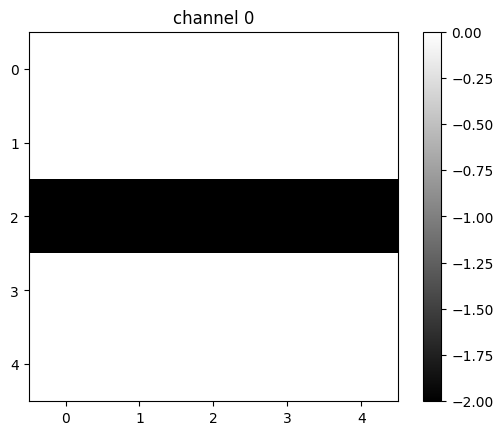

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]) 
 ************************************************************ 



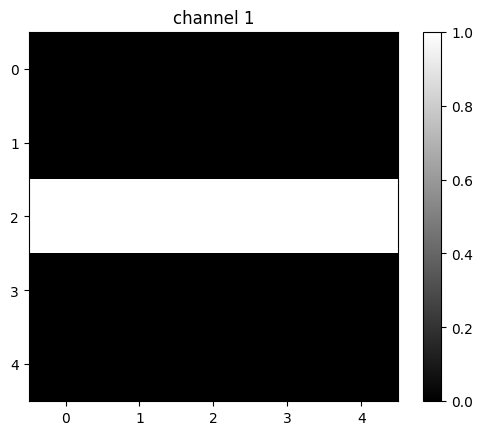

In [ ]:
image2=torch.zeros(1,2,5,5) # (batch_size,number_of_channels,height,width)
image2[0,0,2,:]=-2
image2[0,1,2,:]=1
print(image2, "\n", "*"*60, "\n")


for channel,image in enumerate(image2[0]):
    plt.imshow(image.detach().numpy(), interpolation='nearest', cmap=plt.cm.gray)
    print(image, "\n", "*"*60, "\n")
    plt.title("channel {}".format(channel))
    plt.colorbar()
    plt.show()

In [ ]:
conv3 = nn.Conv2d(in_channels=2, out_channels=1,kernel_size=3)

print(conv3.weight.shape, "\n", "*"*60, "\n")

Gx1=torch.tensor([[0.0,0.0,0.0],[0,1.0,0],[0.0,0.0,0.0]])
conv3.state_dict()['weight'][0][0]=1*Gx1
conv3.state_dict()['weight'][0][1]=-2*Gx1
conv3.state_dict()['bias'][:]=torch.tensor([0.0])


print(conv3.state_dict()['weight'], "\n", "*"*60, "\n")
print(conv3.state_dict()['bias'], "\n", "*"*60, "\n")

conv3(image2)

torch.Size([1, 2, 3, 3]) 
 ************************************************************ 

tensor([[[[ 0.,  0.,  0.],
          [ 0.,  1.,  0.],
          [ 0.,  0.,  0.]],

         [[-0., -0., -0.],
          [-0., -2., -0.],
          [-0., -0., -0.]]]]) 
 ************************************************************ 

tensor([0.]) 
 ************************************************************ 



tensor([[[[ 0.,  0.,  0.],
          [-4., -4., -4.],
          [ 0.,  0.,  0.]]]], grad_fn=<ConvolutionBackward0>)

The following images summarize the process. The object performs Convolution.

<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.2_two_channal_example.png" width = 750, align = "center">


Then, it adds the result:

<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.2_two_channal_example2.png" width = 750, align = "center">


### Case 3: Multiple Input and Multiple Output Channels

When using multiple inputs and outputs, a kernel is created for each input, and the process is repeated for each output. The process is summarized in the following image.

There are two input channels and 3 output channels. For each channel, the input in red and purple is convolved with an individual kernel that is colored differently. As a result, there are three outputs.


<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.2mulit_input_output.png" width = 750, align = "center">


In [ ]:
conv4 = nn.Conv2d(in_channels=2, out_channels=3,kernel_size=3)

print(conv4.weight.shape, "\n", "*"*60, "\n")

conv4.state_dict()['weight'][0][0]=torch.tensor([[0.0,0.0,0.0],[0,0.5,0],[0.0,0.0,0.0]]) # Kernel_1, Channel_1
conv4.state_dict()['weight'][0][1]=torch.tensor([[0.0,0.0,0.0],[0,0.5,0],[0.0,0.0,0.0]]) # Kernel_1, Channel_2

conv4.state_dict()['weight'][1][0]=torch.tensor([[0.0,0.0,0.0],[0,1,0],[0.0,0.0,0.0]]) # Kernel_2, Channel_1
conv4.state_dict()['weight'][1][1]=torch.tensor([[0.0,0.0,0.0],[0,-1,0],[0.0,0.0,0.0]]) # Kernel_2, Channel_2

conv4.state_dict()['weight'][2][0]=torch.tensor([[1.0,0,-1.0],[2.0,0,-2.0],[1.0,0.0,-1.0]]) # Kernel_3, Channel_1
conv4.state_dict()['weight'][2][1]=torch.tensor([[1.0,2.0,1.0],[0.0,0.0,0.0],[-1.0,-2.0,-1.0]]) # Kernel_3, Channel_2

conv4.state_dict()['bias'][:]=torch.tensor([0.0,0.0,0.0])

torch.Size([3, 2, 3, 3]) 
 ************************************************************ 



tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]]) 
 ************************************************************ 



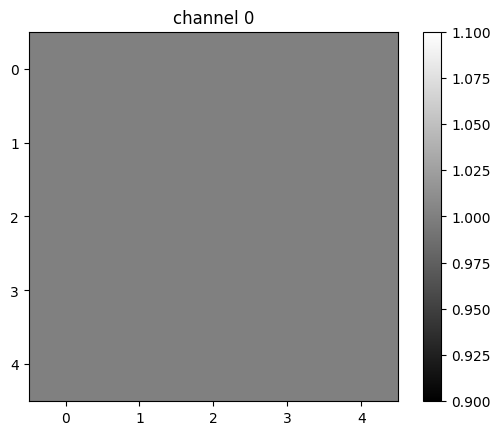

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]]) 
 ************************************************************ 



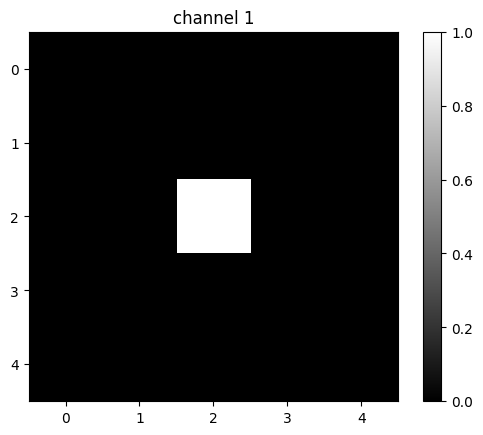

In [ ]:
# 2 channel image
image4=torch.zeros(1,2,5,5)
image4[0][0]=torch.ones(5,5)
image4[0][1][2][2]=1
for channel,image in enumerate(image4[0]):
    plt.imshow(image.detach().numpy(), interpolation='nearest', cmap=plt.cm.gray)
    print(image, "\n", "*"*60, "\n")
    plt.title("channel {}".format(channel))
    plt.colorbar()
    plt.show()

In [ ]:
# perform conv
z=conv4(image4)
z

tensor([[[[ 0.5000,  0.5000,  0.5000],
          [ 0.5000,  1.0000,  0.5000],
          [ 0.5000,  0.5000,  0.5000]],

         [[ 1.0000,  1.0000,  1.0000],
          [ 1.0000,  0.0000,  1.0000],
          [ 1.0000,  1.0000,  1.0000]],

         [[-1.0000, -2.0000, -1.0000],
          [ 0.0000,  0.0000,  0.0000],
          [ 1.0000,  2.0000,  1.0000]]]], grad_fn=<ConvolutionBackward0>)

The output of the first channel is given by:
<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.2_%20multi_channel_1.png" width = 750, align = "center">

The output of the second channel is given by:
<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.2_%20multi_channel_2.png" width = 750, align = "center">

The output of the third channel is given by:
<img src = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0110EN/notebook_images%20/chapter%206/6.1.2_%20multi_channel_3.png" width = 750, align = "center">


# CNN: MNIST data

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import matplotlib.pylab as plt
import numpy as np

In [ ]:
IMAGE_SIZE = 16

#Define transforms
composed = transforms.Compose([transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
                               transforms.ToTensor()])

#Make training dataset
train_dataset = dsets.MNIST(root='./data', train=True, download=True, transform=composed)
# Make the validating
validation_dataset = dsets.MNIST(root='./data', train=False, download=True, transform=composed)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 340kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.61MB/s]


## Build a Convolutional Neural Network Class

Build a Convolutional Network class with two Convolutional layers and one fully connected layer. Pre-determine the size of the final output matrix. The parameters in the constructor are the number of output channels for the first and second layer.


* `self.dropout1 = nn.Dropout(dropout_prob)` and `self.dropout2 = nn.Dropout(dropout_prob)`: These lines define dropout layers. Dropout is a regularization technique that randomly sets a fraction of input units to zero at each update during training, which helps prevent overfitting. The `dropout_prob` parameter determines the probability of a neuron being dropped.

* `self.cnn1 = nn.Conv2d(...)` and `self.cnn2 = nn.Conv2d(...)`: These define two 2D convolutional layers. A `Conv2d` layer applies a convolution operation over an input image.
  * `in_channels`: The number of channels in the input image (here, 1 for grayscale images like MNIST).
  * `out_channels`: The number of filters (kernels) the convolutional layer will use, which also determines the number of output channels.
  * `kernel_size`: The size of the convolutional kernel (e.g., 5x5).
  * `padding`: The amount of zero-padding added to the input. Padding helps preserve the spatial dimensions of the input image, especially around the borders.

* `self.maxpool1 = nn.MaxPool2d(kernel_size=2)` and `self.maxpool2 = nn.MaxPool2d(kernel_size=2)`: These define two max-pooling layers. Max-pooling is a down-sampling technique that takes the maximum value over a window (defined by `kernel_size`) in the input. This helps reduce the spatial dimensions, computation, and extracts robust features.

* `self.fc1 = nn.Linear(out_2 * 4 * 4, 10)`: This defines a fully connected (linear) layer. It takes the flattened output from the preceding convolutional and pooling layers and maps it to the final number of output classes, which is 10 for the MNIST dataset (digits 0-9). The `out_2 * 4 * 4` calculates the input size to this layer, assuming the image has been processed through the convolutional and pooling layers, resulting in a 4x4 feature map with out_2 channels.

In [ ]:
class CNN(nn.Module):
    # Constructor
    def __init__(self, out_1=16, out_2=32, dropout_prob=0.5):
        super(CNN, self).__init__()
        self.dropout1 = nn.Dropout(dropout_prob)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=out_1, kernel_size=5, padding=2)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)

        self.dropout2 = nn.Dropout(dropout_prob)
        self.cnn2 = nn.Conv2d(in_channels=out_1, out_channels=out_2, kernel_size=5, stride=1, padding=2)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)

        self.fc1 = nn.Linear(out_2 * 4 * 4, 10)

    # Prediction
    def forward(self, x):
        x = self.cnn1(x)
        x = self.dropout1(x)
        x = torch.relu(x)
        x = self.maxpool1(x)

        x = self.cnn2(x)
        x = self.dropout2(x)
        x = torch.relu(x)
        x = self.maxpool2(x)

        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

### Define the Convolutional Neural Network Classifier, Criterion function, Optimizer and Train the Model

In [ ]:
# Create the model object using CNN class
model = CNN(out_1=16, out_2=32)

* Define the loss function, the optimizer and the dataset loader


In [ ]:
criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=100)
validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=5000)

* Train the model and determine validation accuracy technically test accuracy

In [ ]:
# Train the model
n_epochs=3
cost_list=[]
accuracy_list=[]
N_test=len(validation_dataset)
COST=0

def train_model(n_epochs):

    for epoch in range(n_epochs):
        COST=0
        model.train()
        for x, y in train_loader:
            optimizer.zero_grad()
            z = model(x)
            loss = criterion(z, y)
            loss.backward() #calculating Gradient
            optimizer.step() # Backpropagate i.e. update the weights of the model
            COST+=loss.data

        cost_list.append(COST)
        correct=0
        #perform a prediction on the validation  data
        model.eval()
        for x_test, y_test in validation_loader:
            z = model(x_test)
            _, yhat = torch.max(z, 1)
            correct += (yhat == y_test).sum().item()
        accuracy = correct / N_test
        accuracy_list.append(accuracy)

train_model(n_epochs)

In [ ]:
a= torch.rand((4,10))
print(a.shape)
print(a)
v,idx=torch.max(a,1)
print(v,idx)

torch.Size([4, 10])
tensor([[0.1675, 0.7720, 0.2212, 0.1215, 0.1943, 0.5683, 0.9013, 0.9250, 0.7659,
         0.8693],
        [0.9734, 0.1027, 0.1136, 0.7341, 0.1955, 0.4691, 0.5950, 0.9647, 0.8993,
         0.6350],
        [0.5006, 0.0309, 0.7932, 0.3520, 0.0555, 0.7696, 0.8558, 0.5761, 0.3810,
         0.7564],
        [0.5487, 0.4962, 0.1232, 0.9302, 0.5462, 0.2251, 0.3855, 0.9887, 0.1457,
         0.3024]])
tensor([0.9250, 0.9734, 0.8558, 0.9887]) tensor([7, 0, 6, 7])


### Plot Acc AND Loss on val dataset

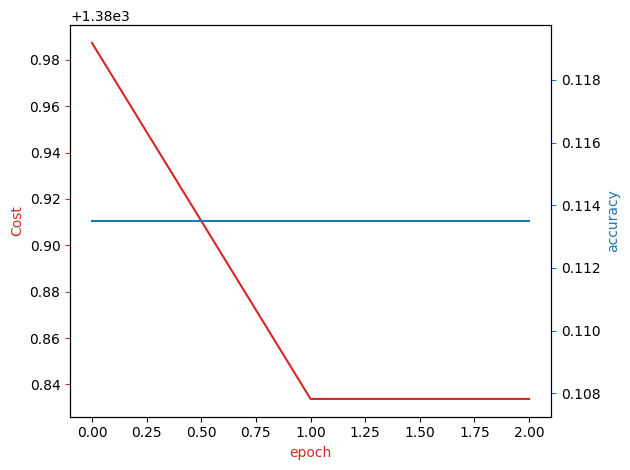

In [ ]:
# Plot the loss and accuracy
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.plot(cost_list, color=color)
ax1.set_xlabel('epoch', color=color)
ax1.set_ylabel('Cost', color=color)
ax1.tick_params(axis='y', color=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('accuracy', color=color)
ax2.set_xlabel('epoch', color=color)
ax2.plot( accuracy_list, color=color)
ax2.tick_params(axis='y', color=color)
fig.tight_layout()

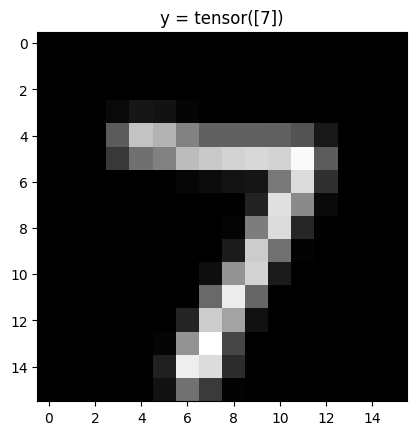

yhat:  tensor([1])


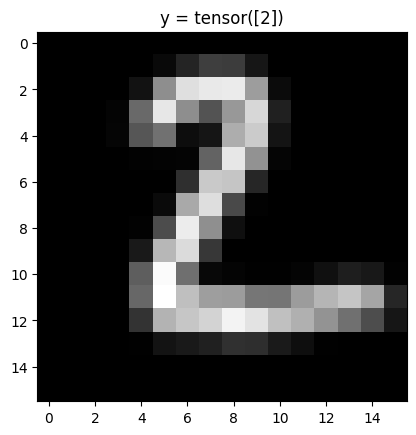

yhat:  tensor([1])


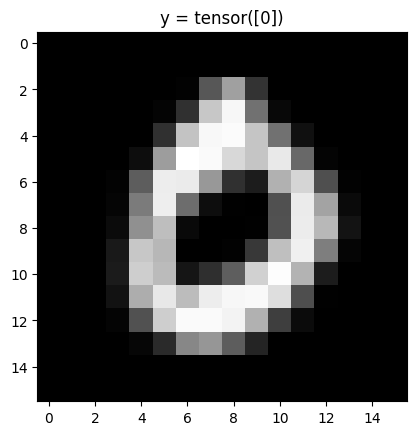

yhat:  tensor([1])


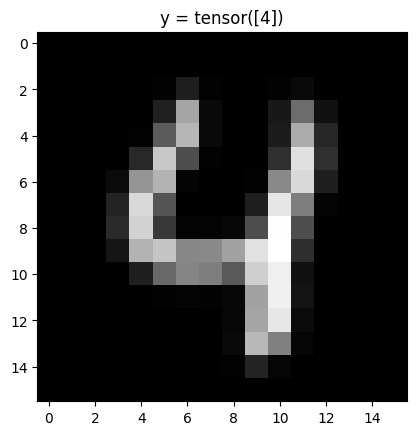

yhat:  tensor([1])


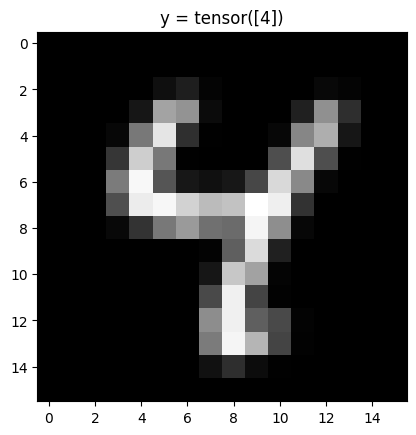

yhat:  tensor([1])


In [ ]:
# Plot the mis-classified samples
def show_data(data_sample):
  # plt.figure(figsize=(3,3))
    plt.imshow(data_sample[0].numpy().reshape(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
    plt.title('y = '+ str(data_sample[1]))

count = 0
for x, y in torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=1):
    z = model(x)
    _, yhat = torch.max(z, 1)
    if yhat != y:
        show_data((x, y))
        plt.show()
        print("yhat: ",yhat)
        count += 1
    if count >= 5:
        break

In [ ]:
!pip install torch-summary

In [ ]:
from torchsummary import summary

model = CNN()
_ = summary(model, (1, 16, 16))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 16, 16, 16]          416
├─Dropout: 1-2                           [-1, 16, 16, 16]          --
├─MaxPool2d: 1-3                         [-1, 16, 8, 8]            --
├─Conv2d: 1-4                            [-1, 32, 8, 8]            12,832
├─Dropout: 1-5                           [-1, 32, 8, 8]            --
├─MaxPool2d: 1-6                         [-1, 32, 4, 4]            --
├─Linear: 1-7                            [-1, 10]                  5,130
Total params: 18,378
Trainable params: 18,378
Non-trainable params: 0
Total mult-adds (M): 0.93
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.07
Estimated Total Size (MB): 0.12


# Different CNN models and their evolution

## **LeNet-5(1998)**

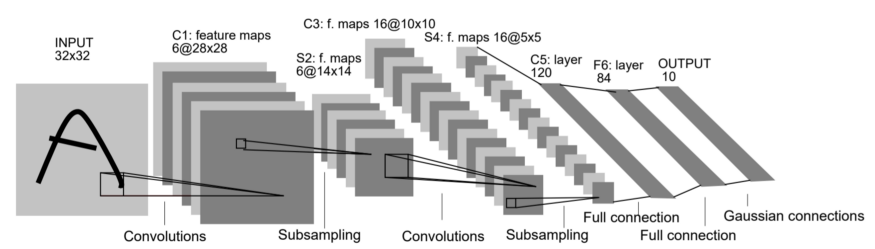

In [ ]:
import torch.nn as nn
from torchsummary import summary
import torch
import torch.nn.functional as F

class LeNet5(nn.Module):

    def __init__(self, n_classes):
        super(LeNet5, self).__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2),
            nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1),
            nn.Tanh()
        )

        self.classifier = nn.Sequential(
            nn.Linear(in_features=120, out_features=84),
            nn.Tanh(),
            nn.Linear(in_features=84, out_features=n_classes),
        )


    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)
        probs = F.softmax(logits, dim=1)
        return logits, probs

model = LeNet5(n_classes = 10)
summary(model,input_size = (1,32,32))

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv2d: 2-1                       156
|    └─Tanh: 2-2                         --
|    └─AvgPool2d: 2-3                    --
|    └─Conv2d: 2-4                       2,416
|    └─Tanh: 2-5                         --
|    └─AvgPool2d: 2-6                    --
|    └─Conv2d: 2-7                       48,120
|    └─Tanh: 2-8                         --
├─Sequential: 1-2                        --
|    └─Linear: 2-9                       10,164
|    └─Tanh: 2-10                        --
|    └─Linear: 2-11                      850
Total params: 61,706
Trainable params: 61,706
Non-trainable params: 0


Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv2d: 2-1                       156
|    └─Tanh: 2-2                         --
|    └─AvgPool2d: 2-3                    --
|    └─Conv2d: 2-4                       2,416
|    └─Tanh: 2-5                         --
|    └─AvgPool2d: 2-6                    --
|    └─Conv2d: 2-7                       48,120
|    └─Tanh: 2-8                         --
├─Sequential: 1-2                        --
|    └─Linear: 2-9                       10,164
|    └─Tanh: 2-10                        --
|    └─Linear: 2-11                      850
Total params: 61,706
Trainable params: 61,706
Non-trainable params: 0

## **AlexNet(2012):**
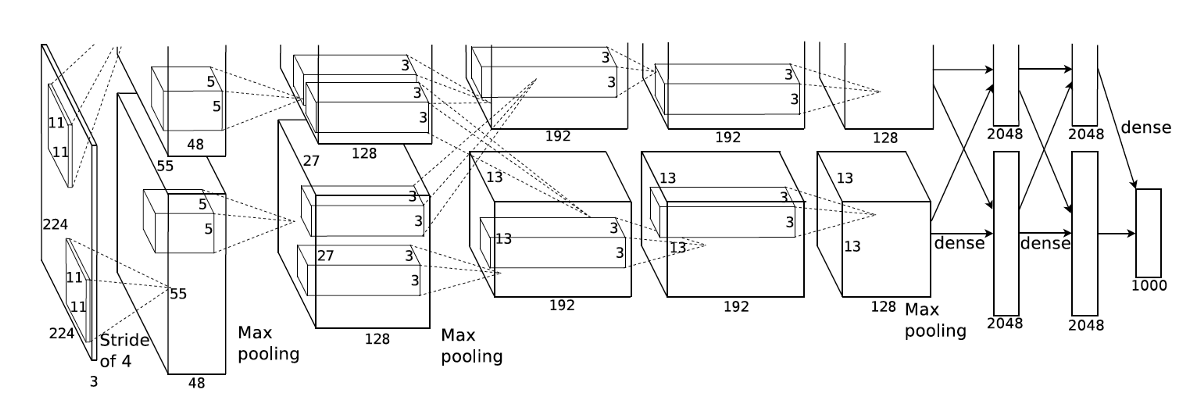

*  Deeper architecture as compared to LeNet-5
*  Dropout was introduced in AlexNet architecture

In [ ]:
import torch.nn as nn
from torchsummary import summary
import torch
import torch.nn.functional as F

class AlexNet(nn.Module):
    def __init__(self, num_classes: int = 1000, dropout: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x: torch.Tensor):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = AlexNet()
summary(model,input_size = (3,224,224))

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv2d: 2-1                       23,296
|    └─ReLU: 2-2                         --
|    └─MaxPool2d: 2-3                    --
|    └─Conv2d: 2-4                       307,392
|    └─ReLU: 2-5                         --
|    └─MaxPool2d: 2-6                    --
|    └─Conv2d: 2-7                       663,936
|    └─ReLU: 2-8                         --
|    └─Conv2d: 2-9                       884,992
|    └─ReLU: 2-10                        --
|    └─Conv2d: 2-11                      590,080
|    └─ReLU: 2-12                        --
|    └─MaxPool2d: 2-13                   --
├─AdaptiveAvgPool2d: 1-2                 --
├─Sequential: 1-3                        --
|    └─Dropout: 2-14                     --
|    └─Linear: 2-15                      37,752,832
|    └─ReLU: 2-16                        --
|    └─Dropout: 2-17                     --
|    └─Linear: 2-18                    

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv2d: 2-1                       23,296
|    └─ReLU: 2-2                         --
|    └─MaxPool2d: 2-3                    --
|    └─Conv2d: 2-4                       307,392
|    └─ReLU: 2-5                         --
|    └─MaxPool2d: 2-6                    --
|    └─Conv2d: 2-7                       663,936
|    └─ReLU: 2-8                         --
|    └─Conv2d: 2-9                       884,992
|    └─ReLU: 2-10                        --
|    └─Conv2d: 2-11                      590,080
|    └─ReLU: 2-12                        --
|    └─MaxPool2d: 2-13                   --
├─AdaptiveAvgPool2d: 1-2                 --
├─Sequential: 1-3                        --
|    └─Dropout: 2-14                     --
|    └─Linear: 2-15                      37,752,832
|    └─ReLU: 2-16                        --
|    └─Dropout: 2-17                     --
|    └─Linear: 2-18                    

## **VGG-16(2015)**:

*  Multiple 3$\times$ 3 convolutions stacked together are capable of replicating bigger receptive fields
*  more nonlinearities present in between them (in terms of activation functions)
*  perform better than their counterparts with bigger receptive fields.



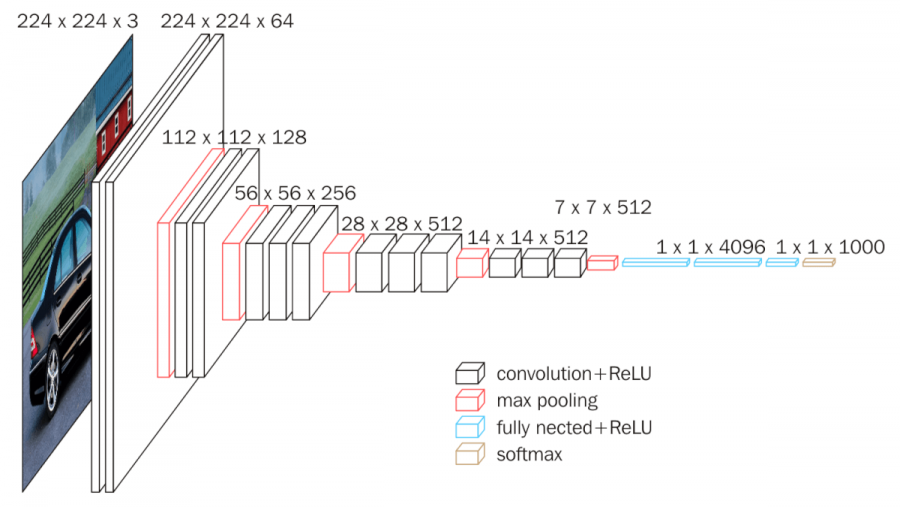

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary
# import torchvision.transforms as transforms
# import matplotlib.pyplot as plt
# import numpy as np
# import random

class VGG16(nn.Module):
    def __init__(self):
        super(VGG16, self).__init__()
        self.conv1_1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)

        self.conv2_1 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)

        self.conv3_1 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.conv3_2 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.conv3_3 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)

        self.conv4_1 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1)
        self.conv4_2 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1)
        self.conv4_3 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1)

        self.conv5_1 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1)
        self.conv5_2 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1)
        self.conv5_3 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1)

        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.dropout = nn.Dropout(p = 0.5)

        self.fc1 = nn.Linear(25088, 4096)
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, 1000)

    def forward(self, x):
        x = F.relu(self.conv1_1(x))
        x = F.relu(self.conv1_2(x))
        x = self.maxpool(x)
        x = F.relu(self.conv2_1(x))
        x = F.relu(self.conv2_2(x))
        x = self.maxpool(x)
        x = F.relu(self.conv3_1(x))
        x = F.relu(self.conv3_2(x))
        x = F.relu(self.conv3_3(x))
        x = self.maxpool(x)
        x = F.relu(self.conv4_1(x))
        x = F.relu(self.conv4_2(x))
        x = F.relu(self.conv4_3(x))
        x = self.maxpool(x)
        x = F.relu(self.conv5_1(x))
        x = F.relu(self.conv5_2(x))
        x = F.relu(self.conv5_3(x))
        x = self.maxpool(x)
        x = x.reshape(x.shape[0], -1) #Flattening to a vector
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        #x = F.dropout(x, 0.5) #dropout was included to combat overfitting
        x = F.relu(self.fc2(x))
        x = F.dropout(x, 0.5)
        x = self.fc3(x)
        return x


model = VGG16()
summary(model, input_size = (3,224,224))

Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            1,792
├─Conv2d: 1-2                            36,928
├─Conv2d: 1-3                            73,856
├─Conv2d: 1-4                            147,584
├─Conv2d: 1-5                            295,168
├─Conv2d: 1-6                            590,080
├─Conv2d: 1-7                            590,080
├─Conv2d: 1-8                            1,180,160
├─Conv2d: 1-9                            2,359,808
├─Conv2d: 1-10                           2,359,808
├─Conv2d: 1-11                           2,359,808
├─Conv2d: 1-12                           2,359,808
├─Conv2d: 1-13                           2,359,808
├─MaxPool2d: 1-14                        --
├─Dropout: 1-15                          --
├─Linear: 1-16                           102,764,544
├─Linear: 1-17                           16,781,312
├─Linear: 1-18                           4,097,000
Total params: 138,357,544
Trainable params: 138,357,544
Non-tr

Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            1,792
├─Conv2d: 1-2                            36,928
├─Conv2d: 1-3                            73,856
├─Conv2d: 1-4                            147,584
├─Conv2d: 1-5                            295,168
├─Conv2d: 1-6                            590,080
├─Conv2d: 1-7                            590,080
├─Conv2d: 1-8                            1,180,160
├─Conv2d: 1-9                            2,359,808
├─Conv2d: 1-10                           2,359,808
├─Conv2d: 1-11                           2,359,808
├─Conv2d: 1-12                           2,359,808
├─Conv2d: 1-13                           2,359,808
├─MaxPool2d: 1-14                        --
├─Dropout: 1-15                          --
├─Linear: 1-16                           102,764,544
├─Linear: 1-17                           16,781,312
├─Linear: 1-18                           4,097,000
Total params: 138,357,544
Trainable params: 138,357,544
Non-tr

In [ ]:
import torchvision
model_pretrained = torchvision.models.vgg16(pretrained = True, progress = True)
summary(model_pretrained, input_size = (3,224,224))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 66.1MB/s]


Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv2d: 2-1                       1,792
|    └─ReLU: 2-2                         --
|    └─Conv2d: 2-3                       36,928
|    └─ReLU: 2-4                         --
|    └─MaxPool2d: 2-5                    --
|    └─Conv2d: 2-6                       73,856
|    └─ReLU: 2-7                         --
|    └─Conv2d: 2-8                       147,584
|    └─ReLU: 2-9                         --
|    └─MaxPool2d: 2-10                   --
|    └─Conv2d: 2-11                      295,168
|    └─ReLU: 2-12                        --
|    └─Conv2d: 2-13                      590,080
|    └─ReLU: 2-14                        --
|    └─Conv2d: 2-15                      590,080
|    └─ReLU: 2-16                        --
|    └─MaxPool2d: 2-17                   --
|    └─Conv2d: 2-18                      1,180,160
|    └─ReLU: 2-19                        --
|    └─Conv2d: 2-20              

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv2d: 2-1                       1,792
|    └─ReLU: 2-2                         --
|    └─Conv2d: 2-3                       36,928
|    └─ReLU: 2-4                         --
|    └─MaxPool2d: 2-5                    --
|    └─Conv2d: 2-6                       73,856
|    └─ReLU: 2-7                         --
|    └─Conv2d: 2-8                       147,584
|    └─ReLU: 2-9                         --
|    └─MaxPool2d: 2-10                   --
|    └─Conv2d: 2-11                      295,168
|    └─ReLU: 2-12                        --
|    └─Conv2d: 2-13                      590,080
|    └─ReLU: 2-14                        --
|    └─Conv2d: 2-15                      590,080
|    └─ReLU: 2-16                        --
|    └─MaxPool2d: 2-17                   --
|    └─Conv2d: 2-18                      1,180,160
|    └─ReLU: 2-19                        --
|    └─Conv2d: 2-20              

## **Inception Net(2015):**

**Inception module (naive version):**
*   Filters of multiple sizes at same lavel
*   Inclusion of maxpool
*   Wider rather than deeper

**Inception module with dimension reductions:**
*   Inclusion of 1 $\times$ 1 convolution before 3 $\times$ 3 and  5 $\times$ 5 convolution and after max pooling for dimension reduction



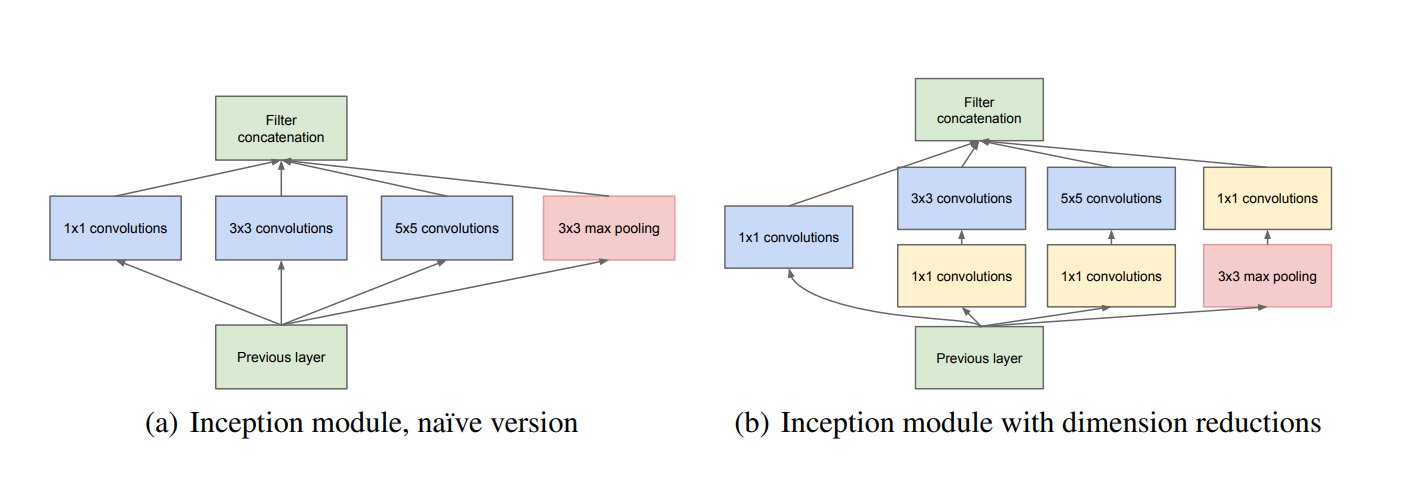

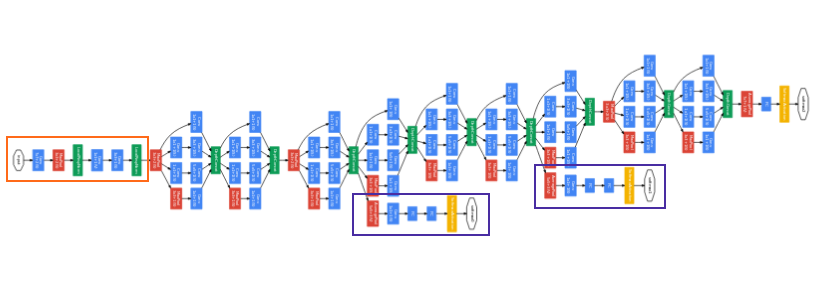

*   Vanishing gradient problem
*   Two auxiliary classifiers


**total_loss = real_loss + 0.3 * aux_loss_1 + 0.3 * aux_loss_2**

In [ ]:
import torch.nn as nn
from torchsummary import summary
import torch
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_chanels, **kwargs):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_chanels, **kwargs)
        self.bn = nn.BatchNorm2d(out_chanels)

    def forward(self, x):
        return F.relu(self.bn(self.conv(x)))

class InceptionBlock(nn.Module):
    def __init__(self,
        in_channels,
        out_1x1,
        red_3x3,
        out_3x3,
        red_5x5,
        out_5x5,
        out_pool):
        super(InceptionBlock, self).__init__()
        self.branch1 = ConvBlock(in_channels, out_1x1, kernel_size=1)
        self.branch2 = nn.Sequential(
            ConvBlock(in_channels, red_3x3, kernel_size=1, padding=0),
            ConvBlock(red_3x3, out_3x3, kernel_size=3, padding=1),
        )
        self.branch3 = nn.Sequential(
            ConvBlock(in_channels, red_5x5, kernel_size=1),
            ConvBlock(red_5x5, out_5x5, kernel_size=5, padding=2),
        )
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, padding=1, stride=1),
            ConvBlock(in_channels, out_pool, kernel_size=1),
        )

    def forward(self, x):
        branch1 = self.branch1(x)
        branch2 = self.branch2(x)
        branch3 = self.branch3(x)
        branch4 = self.branch4(x)
        output = torch.cat((branch1,branch2,branch3,branch4),dim =  1)
        return output

model = InceptionBlock(in_channels=192,
        out_1x1 = 64,
        red_3x3 = 96,
        out_3x3 = 128,
        red_5x5 = 16,
        out_5x5 = 32,
        out_pool = 32,)

# summary(model,input_size = (192,28,28))

input = torch.randn(1,192,28,28)
output = model(input)
print(output.shape)

torch.Size([1, 256, 28, 28])


## **ResNet(2016):**

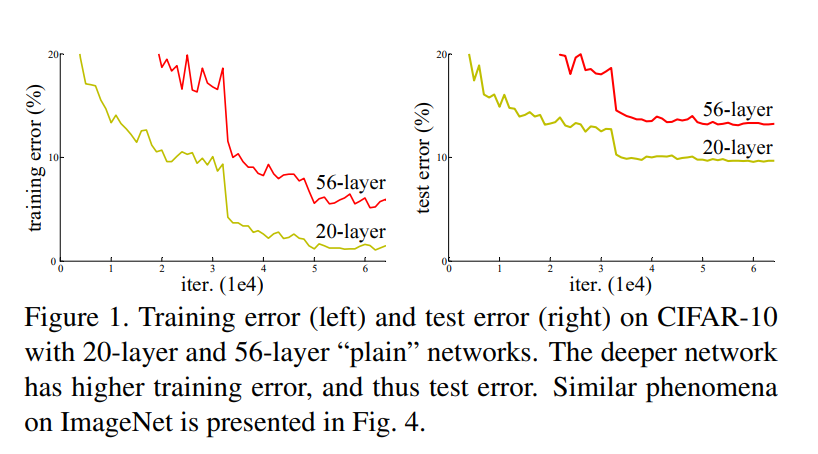

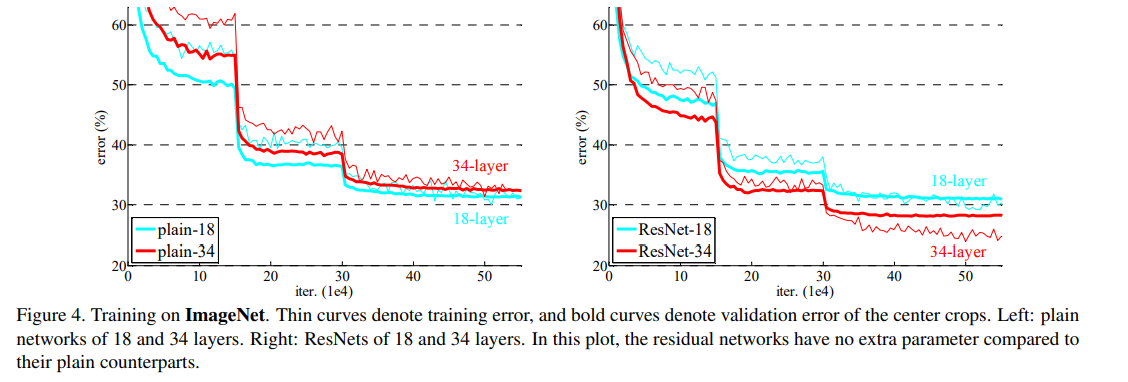

* **Residual Block:**


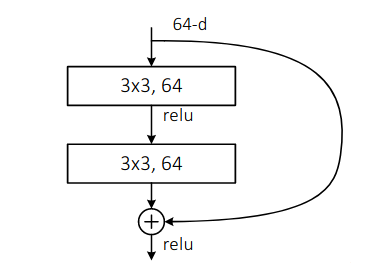

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class residual_block(nn.Module):
  def __init__(self):
      super(residual_block, self).__init__()

      self.conv1 = nn.Conv2d(64, 64, 3,1,1)
      self.conv2 = nn.Conv2d(64,64,3,1,1)
      self.skip = nn.Identity()

  def forward(self,x):
    x = F.relu(self.conv1(x))
    x = self.conv2(x)
    out = x + self.skip(x)
    out = F.relu(out)


In [ ]:
import torch
model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
# or any of these variants
# model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet34', pretrained=True)
# model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', pretrained=True)
# model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet101', pretrained=True)
# model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet152', pretrained=True)
model.eval()

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to /root/.cache/torch/hub/v0.10.0.zip


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 151MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## **Other popular CNN architectures:**

*  EfficientNet (model scaling, Squeeze and Excitation layers)
*  MobileNet (depth wise seprable convolution [https://www.geeksforgeeks.org/depth-wise-separable-convolutional-neural-networks/])
*  DenseNet (each layer to every layer in feedward fashion)



### **EfficientNet:**
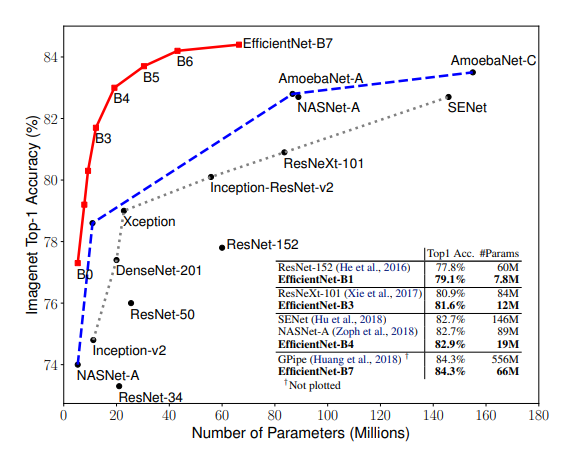

### **DenseNet:**
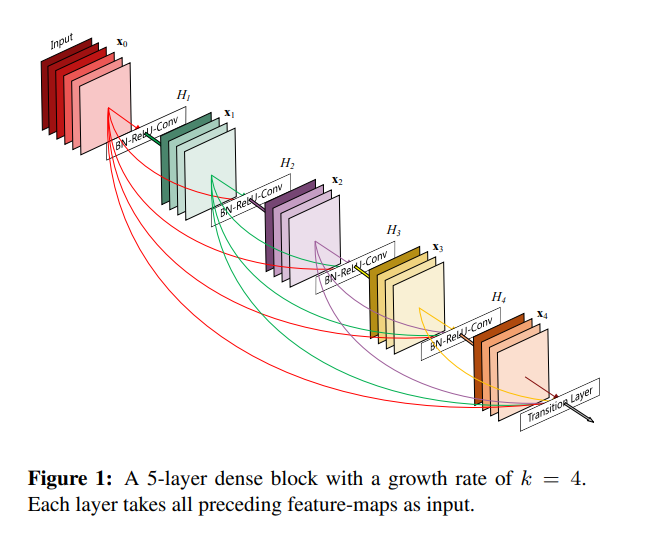

\begin{equation}
k^{[l]} = k^{[0]}+k(l-1)
\end{equation}

# **Transfer Learning**
Transfer learning is a deep learning technique where a model trained on one task (source task) is reused and adapted for a different but related task (target task).
1.   Fine Tuning
2.   Use model as fixed feature extractor

## Fine Tuning

In [ ]:
import torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model_ft = torchvision.models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

## **Use pretrained model as fixed feature extrcator:**

In [ ]:
import torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model_conv = torchvision.models.resnet18(pretrained=True)
for param in model_conv.parameters():
    param.requires_grad = False # param.requires_grad, tells whether gradients should be computed and stored for a parameter during backpropagation.

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
